In [4]:
import spacy
from grakel import GraphKernel, Graph
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

# Load SpaCy model for entity and relationship extraction
nlp = spacy.load("en_core_web_sm")

# Define sentences
sentences = {
    "S1": ["The cat sat on the mat.",
           "A cat was sitting on the mat.",
           "On the mat, there was a cat sitting.",
           "Sitting on the mat was a cat.",
           "The mat had a cat sitting on it."],
    "S2": ["The dog barked loudly at the stranger.",
           "Loudly, the dog barked at the stranger.",
           "At the stranger, the dog barked loudly.",
           "The stranger was barked at loudly by the dog.",
           "A loud bark was directed at the stranger by the dog."],
    "S3": ["Three people are talking.",
           "A girl is dancing in the stadium."]
}

# Function to extract entities and relationships from a sentence
def extract_entities_and_relationships(sentence):
    doc = nlp(sentence)
    entities = [(ent.text, ent.label_) for ent in doc.ents]
    relationships = []
    for token in doc:
        if token.dep_ == "ROOT":
            for child in token.children:
                if child.dep_ in ["nsubj", "dobj", "prep"]:
                    relationships.append((token.text, child.text))
    # Use noun chunks if entities are not detected
    if not entities:
        for chunk in doc.noun_chunks:
            entities.append((chunk.text, 'NOUN_CHUNK'))
    return entities, relationships

# Function to construct a graph from entities and relationships
def construct_graph(entities, relationships):
    G = nx.DiGraph()
    for entity, label in entities:
        G.add_node(entity, label=label)
    for subj, obj in relationships:
        if not G.has_node(subj):
            G.add_node(subj, label="unknown")
        if not G.has_node(obj):
            G.add_node(obj, label="unknown")
        G.add_edge(subj, obj)
    return G

# Extract entities and relationships, then construct graphs
graphs = []
for key, variations in sentences.items():
    for sentence in variations:
        entities, relationships = extract_entities_and_relationships(sentence)
        G = construct_graph(entities, relationships)
        graphs.append(G)

# Ensure all nodes have labels and labels are strings
for G in graphs:
    for node in G.nodes:
        if 'label' not in G.nodes[node]:
            G.nodes[node]['label'] = 'unknown'
        G.nodes[node]['label'] = str(G.nodes[node]['label'])

# Verify the graph nodes and labels
for G in graphs:
    print("Graph Nodes and Labels:", G.nodes(data=True))

# Convert NetworkX graphs to GraKeL graphs
grakel_graphs = []
for G in graphs:
    if len(G.nodes) > 0 and len(G.edges) > 0:  # Ensure graph is not empty
        node_labels = {i: G.nodes[node]['label'] for i, node in enumerate(G.nodes)}
        edges = [(list(G.nodes).index(u), list(G.nodes).index(v)) for u, v in G.edges()]
        grakel_graphs.append(Graph(edges, node_labels=node_labels))

# Compute Weisfeiler-Lehman kernel
gk = GraphKernel(kernel={"name": "weisfeiler_lehman"}, normalize=True)
K = gk.fit_transform(grakel_graphs)

# Print kernel matrix
print("Kernel matrix:\n", K)

# Quantify uncertainty (1 - similarity score)
# Average similarity for each sentence group
uncertainty = {}
index = 0
for key, variations in sentences.items():
    similarities = []
    for i in range(len(variations)):
        for j in range(i + 1, len(variations)):
            if index + i < len(K) and index + j < len(K):
                similarities.append(K[index + i, index + j])
    uncertainty[key] = 1 - np.mean(similarities) if similarities else 1
    index += len(variations)

# Print uncertainty
for key, value in uncertainty.items():
    print(f"Uncertainty for {key}: {value:.4f}")

Graph Nodes and Labels: [('The cat', {'label': 'NOUN_CHUNK'}), ('the mat', {'label': 'NOUN_CHUNK'}), ('sat', {'label': 'unknown'}), ('cat', {'label': 'unknown'}), ('on', {'label': 'unknown'})]
Graph Nodes and Labels: [('A cat', {'label': 'NOUN_CHUNK'}), ('the mat', {'label': 'NOUN_CHUNK'}), ('sitting', {'label': 'unknown'}), ('cat', {'label': 'unknown'}), ('on', {'label': 'unknown'})]
Graph Nodes and Labels: [('the mat', {'label': 'NOUN_CHUNK'}), ('was', {'label': 'unknown'}), ('On', {'label': 'unknown'})]
Graph Nodes and Labels: [('the mat', {'label': 'NOUN_CHUNK'}), ('a cat', {'label': 'NOUN_CHUNK'})]
Graph Nodes and Labels: [('The mat', {'label': 'NOUN_CHUNK'}), ('a cat', {'label': 'NOUN_CHUNK'}), ('it', {'label': 'NOUN_CHUNK'}), ('had', {'label': 'unknown'}), ('mat', {'label': 'unknown'}), ('cat', {'label': 'unknown'})]
Graph Nodes and Labels: [('The dog', {'label': 'NOUN_CHUNK'}), ('the stranger', {'label': 'NOUN_CHUNK'})]
Graph Nodes and Labels: [('Loudly, the dog', {'label': 'NO

ValueError: num must be an integer with 1 <= num <= 9, not 10

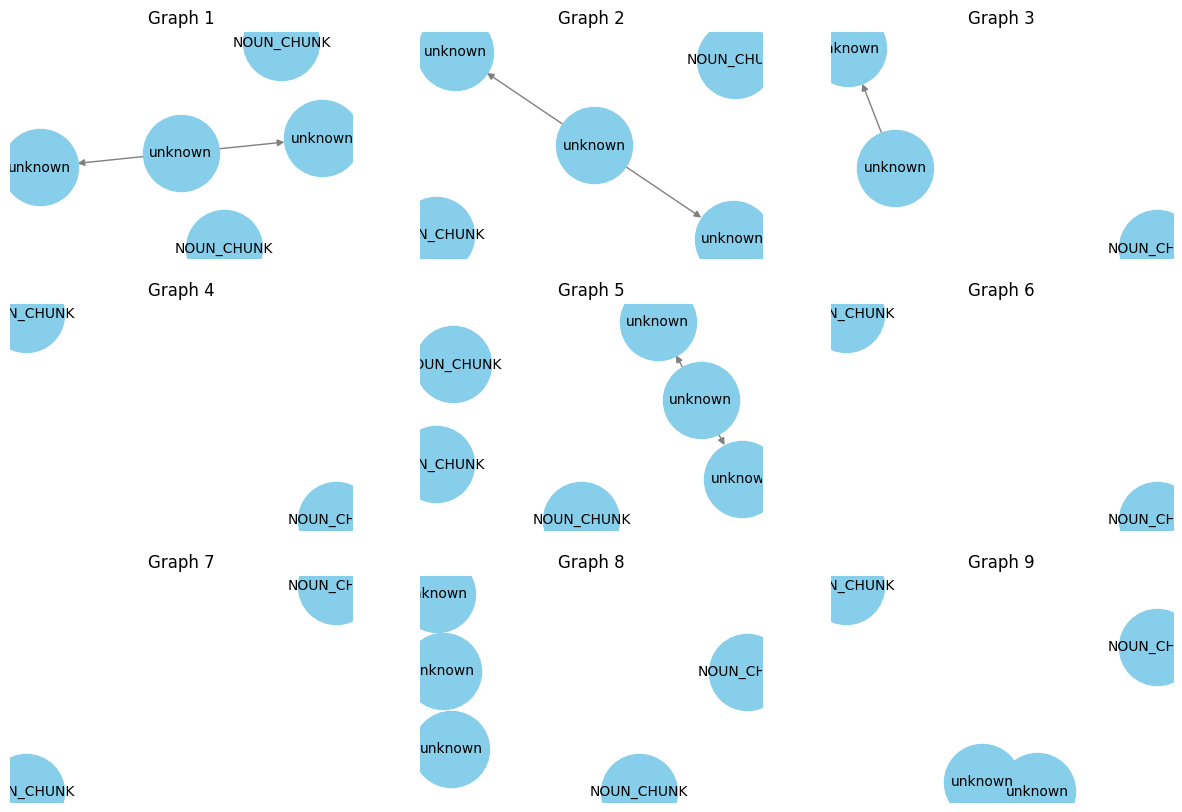

In [ ]:

# Visualize the graphs
def visualize_graphs(graphs, titles):
    plt.figure(figsize=(15, 10))
    for i, G in enumerate(graphs):
        plt.subplot(3, 3, i + 1)
        pos = nx.spring_layout(G)
        labels = nx.get_node_attributes(G, 'label')
        nx.draw(G, pos, labels=labels, with_labels=True, node_color='skyblue', edge_color='gray', node_size=3000, font_size=10)
        plt.title(titles[i])
    plt.tight_layout()
    plt.show()

# Titles for the graphs
titles = [f"Graph {i + 1}" for i in range(len(graphs))]

# Visualize the graphs
visualize_graphs(graphs, titles)

In [3]:
!pip install grakel
!pip install networkx
!pip install spacy
!python -m spacy download en_core_web_sm


  Using cached joblib-1.4.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached threadpoolctl-3.5.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 28.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 87.4 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.3/491.3 kB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 90.6 MB/s eta 0:00:00:00:0100:01
Using cached joblib-1.4.2-py3-none-any.whl (301 kB)
Using cached threadpoolctl-3.5.0-py3-none-any.whl (18 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 83.0 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
